# Understanding the Hyperparameters

Every `AnalyticKernel` and `GPSolver` instance is configured with a single Python dict called `hparam`.  This notebook explains what each key controls, which keys are required, and which keys are specific to each envelope model.

---

## The kernel formula

The GP kernel is

$$K(\tau) = \sigma_k^2 \, R_\Gamma(\tau) \sum_{n=0}^{N} |c_n(\phi)|^2 \cos\!\bigl(n\,\omega_0(\phi)\,\tau\bigr)$$

averaged over spot latitude $\phi$, where

| Symbol | Meaning |
|:---|:---|
| $\sigma_k$ | overall kernel amplitude |
| $R_\Gamma(\tau) = \int \Gamma(t)\,\Gamma(t+\tau)\,dt$ | autocorrelation of the squared spot envelope $\Gamma(t) = \alpha^2(t)/\alpha_{\rm max}^2$ |
| $c_n(\phi)$ | Fourier coefficients of the spot visibility function at latitude $\phi$ |
| $\omega_0(\phi) = 2\pi\,(1 - \kappa\sin^2\!\phi)\,/\,P_{\rm eq}$ | latitude-dependent rotation frequency |

The `hparam` dict sets all of these quantities.  Parameters split into three groups:

1. **Rotation geometry** — shape and period of the oscillations in $K(\tau)$
2. **Amplitude** — the overall scale $\sigma_k$
3. **Envelope shape** — the decay profile $R_\Gamma(\tau)$

In [1]:
import sys
sys.path.append("../..")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import erf

from src_jax.params import (
    resolve_hparam,
    BASE_REQUIRED_KEYS, KERNEL_HPARAM_KEYS, HPARAM_KEYS_WITH_NOISE,
)
from src_jax.analytic_kernel import AnalyticKernel, compute_R_Gamma_numerical, _skew_normal_envelope_func

# Reference hparam used throughout (symmetric trapezoid)
hparam_ref = dict(
    peq=5.0, kappa=0.2, inc=np.pi / 3,
    lspot=10.0, tau=3.0,
    sigma_k=0.01,
)

---
## `resolve_hparam` — validation and normalization

Before any kernel or solver is built, the raw dict is passed through `resolve_hparam`, which:

1. Checks that the **base required keys** (`peq`, `kappa`, `inc`, `lspot`) are present.
2. Auto-detects the **envelope type** from the registered `EnvelopeSpec` table (most-specific match wins) and injects derived keys such as a scalar `tau`.
3. Auto-detects the **amplitude mode** and injects `sigma_k`.

The returned dict always contains `tau` and `sigma_k`, regardless of how they were specified in the input.

In [2]:
# Provide amplitude as nspot_rate instead of sigma_k directly
raw = dict(peq=5.0, kappa=0.2, inc=np.pi/3, lspot=10.0, tau=3.0,
           nspot_rate=0.4, fspot=0.0, alpha_max=0.05)

resolved = resolve_hparam(raw)
print("Input keys :  ", sorted(raw.keys()))
print("Resolved keys:", sorted(resolved.keys()))
print(f"\nInjected sigma_k = {resolved['sigma_k']:.6f}")
print(f"  = sqrt(nspot_rate) * (1-fspot) * alpha_max^2")
print(f"  = sqrt({raw['nspot_rate']}) * {1-raw['fspot']} * {raw['alpha_max']}^2")
print(f"  = {np.sqrt(raw['nspot_rate']) * (1-raw['fspot']) * raw['alpha_max']**2:.6f}")

Input keys :   ['alpha_max', 'fspot', 'inc', 'kappa', 'lspot', 'nspot_rate', 'peq', 'tau']
Resolved keys: ['alpha_max', 'fspot', 'inc', 'kappa', 'lspot', 'nspot_rate', 'peq', 'sigma_k', 'tau']

Injected sigma_k = 0.001581
  = sqrt(nspot_rate) * (1-fspot) * alpha_max^2
  = sqrt(0.4) * 1.0 * 0.05^2
  = 0.001581


---
## 1 — Rotation geometry parameters

These four keys appear in every `hparam` dict regardless of which envelope is used.

| Key | Description | Units | Effect on kernel |
|:---|:---|:---|:---|
| `peq` | Equatorial rotation period | days | Sets the spacing of the oscillation peaks: $K(\tau)$ peaks at integer multiples of $P_{\rm eq}$ |
| `kappa` | Differential rotation shear $\kappa$ | dimensionless $\in(0,1)$ | Broadens each peak; spots at different latitudes rotate at different rates $\omega_0(\phi) = (2\pi/P_{\rm eq})(1-\kappa\sin^2\!\phi)$ |
| `inc` | Stellar inclination $i$ | radians $\in(0,\pi)$ | Controls harmonic amplitudes $|c_n|^2$; equatorial view ($i=\pi/2$) maximises the first harmonic; pole-on ($i\approx 0$) suppresses all modulation |
| `lspot` | Spot plateau duration | days | Duration of the flat-top phase of the trapezoidal envelope; **not used by the skew-normal envelope** (set to `0`) |

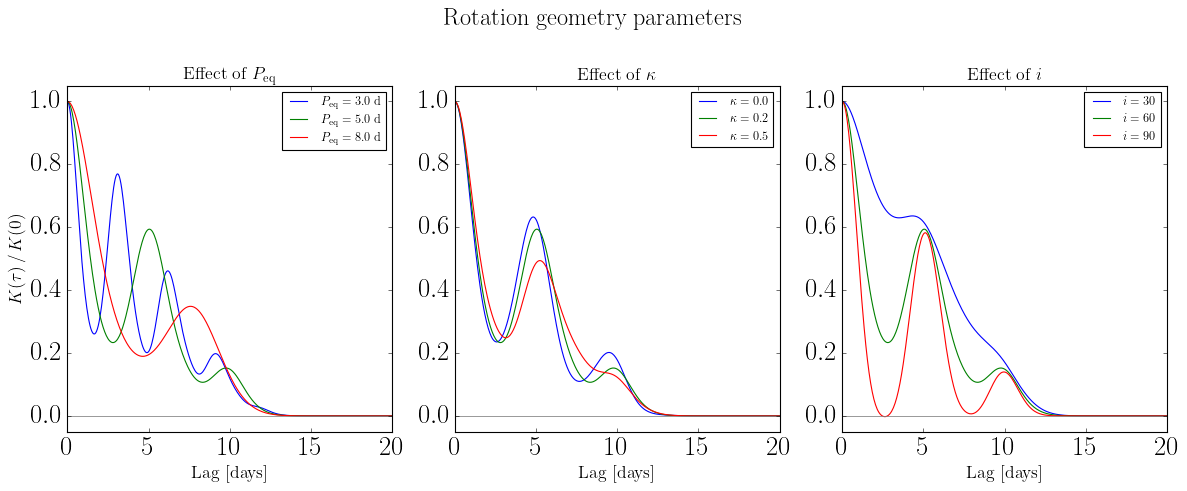

In [6]:
lags = np.linspace(0, 40, 800)

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=False)

# --- vary peq ---
ax = axes[0]
for peq in [3.0, 5.0, 8.0]:
    h = dict(hparam_ref, peq=peq)
    k = AnalyticKernel(h, n_harmonics=3)
    K = k.kernel(lags)
    ax.plot(lags, K / K[0], label=f"$P_{{\\rm eq}}={peq}$ d")
ax.set_xlabel("Lag [days]", fontsize=16)
ax.set_ylabel(r"$K(\tau)\,/\,K(0)$", fontsize=16)
ax.set_title("Effect of $P_{\\rm eq}$", fontsize=16)
ax.axhline(0, color="gray", lw=0.7)
ax.legend(fontsize=11)

# --- vary kappa ---
ax = axes[1]
for kappa in [0.0, 0.2, 0.5]:
    h = dict(hparam_ref, kappa=kappa)
    k = AnalyticKernel(h, n_harmonics=3)
    K = k.kernel(lags)
    ax.plot(lags, K / K[0], label=f"$\\kappa={kappa}$")
ax.set_xlabel("Lag [days]", fontsize=16)
ax.set_title("Effect of $\\kappa$", fontsize=16)
ax.axhline(0, color="gray", lw=0.7)
ax.legend(fontsize=11)

# --- vary inc ---
ax = axes[2]
for inc, label in [(np.pi/6, "$i=30°$"), (np.pi/3, "$i=60°$"), (np.pi/2, "$i=90°$")]:
    h = dict(hparam_ref, inc=inc)
    k = AnalyticKernel(h, n_harmonics=3)
    K = k.kernel(lags)
    ax.plot(lags, K / K[0], label=label)
ax.set_xlabel("Lag [days]", fontsize=16)
ax.set_title("Effect of $i$", fontsize=16)
ax.axhline(0, color="gray", lw=0.7)
ax.legend(fontsize=11)

for ax in axes:
    ax.set_xlim(0, 20)
    ax.set_ylim(-0.05, 1.05)

fig.suptitle("Rotation geometry parameters", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

---
## 2 — Amplitude parameterizations

`resolve_hparam` accepts three mutually exclusive ways to set the kernel amplitude $\sigma_k$.  The most-specific matching set of keys wins (larger signature wins over smaller).

| Mode | Required keys | Formula | Notes |
|:---|:---|:---|:---|
| **Direct** | `sigma_k` | $\sigma_k$ as provided | Simplest; use when $\sigma_k$ is already known |
| **Physical rate** *(preferred)* | `nspot_rate`, `fspot`, `alpha_max` | $\sigma_k = \sqrt{\dot{N}_{\rm spot}}\,(1 - f_{\rm spot})\,\alpha_{\rm max}^2$ | $\dot{N}_{\rm spot}$ is the emergence rate [spots/day]; independent of simulation length |
| **Physical count** *(legacy)* | `nspot`, `fspot`, `alpha_max` | $\sigma_k = \sqrt{N_{\rm spot}}\,(1 - f_{\rm spot})\,\alpha_{\rm max}^2\,/\,\pi$ | $N_{\rm spot}$ is the total spot count; biased by the simulation duration $T_{\rm sim}$; prefer `physical_rate` |

The relationship between rate and count is $\dot{N}_{\rm spot} = N_{\rm spot}\,/\,(\ell_{\rm spot} + 2\tau)$, the average number of spots active at any one time.

In [7]:
# All three modes produce the same sigma_k for matched physical parameters
alpha_max = 0.05
fspot     = 0.1
nspot_rate = 0.4          # spots/day
# nspot equivalent: nspot = nspot_rate * (lspot + 2*tau) = 0.4 * (10 + 6) = 6.4
nspot = nspot_rate * (hparam_ref["lspot"] + 2 * hparam_ref["tau"])

base = dict(peq=5.0, kappa=0.2, inc=np.pi/3, lspot=10.0, tau=3.0)

modes = [
    ("direct",          {**base, "sigma_k": np.sqrt(nspot_rate) * (1-fspot) * alpha_max**2}),
    ("physical_rate",   {**base, "nspot_rate": nspot_rate, "fspot": fspot, "alpha_max": alpha_max}),
    ("physical_count",  {**base, "nspot": nspot, "fspot": fspot, "alpha_max": alpha_max}),
]

print(f"{'Mode':<20}  {'sigma_k':>10}")
print("-" * 34)
for name, h in modes:
    r = resolve_hparam(h)
    print(f"{name:<20}  {r['sigma_k']:>10.7f}")

print("\nNote: 'direct' and 'physical_rate' agree exactly.")
print("      'physical_count' matches when nspot = nspot_rate * (lspot + 2*tau).")

Mode                     sigma_k
----------------------------------
direct                 0.0014230
physical_rate          0.0014230
physical_count         0.0018119

Note: 'direct' and 'physical_rate' agree exactly.
      'physical_count' matches when nspot = nspot_rate * (lspot + 2*tau).


---
## 3 — Envelope shape parameters

The envelope $\Gamma(t) = \alpha^2(t)/\alpha_{\rm max}^2$ describes how the squared spot area evolves over the spot's lifetime.  Its autocorrelation $R_\Gamma(\tau)$ sets the timescale over which the kernel decays between rotation peaks.

Three envelope models are built in.  Each is identified by a distinct set of **signature keys** in `hparam`:

| Envelope | Signature keys | Envelope parameters | `lspot` used? |
|:---|:---|:---|:---|
| Symmetric trapezoid | `tau` | `lspot`, `tau` | Yes |
| Asymmetric trapezoid | `tau_em`, `tau_dec` | `lspot`, `tau_em`, `tau_dec` | Yes |
| Skew-normal | `sigma_sn`, `n_sn` | `sigma_sn`, `n_sn` | No (set to `0`) |

Detection is automatic: just include the right keys in `hparam` and `resolve_hparam` (called internally by `AnalyticKernel`) picks the correct model.

---
### 3.1 Symmetric trapezoid

**Signature key:** `tau`

The spot area rises linearly over emergence timescale $\tau$, holds a plateau of duration $\ell_{\rm spot}$, then decays symmetrically over another $\tau$.  The total spot lifetime is $\ell_{\rm spot} + 2\tau$.

$$\Gamma_{\rm sym}(t) = \left(\frac{\alpha(t)}{\alpha_{\rm max}}\right)^2, \qquad
\frac{\alpha(t)}{\alpha_{\rm max}} = \begin{cases}
\dfrac{t + \ell/2 + \tau}{\tau} & -\ell/2 - \tau \le t < -\ell/2 \\[6pt]
1 & -\ell/2 \le t \le \ell/2 \\[6pt]
\dfrac{\ell/2 + \tau - t}{\tau} & \ell/2 < t \le \ell/2 + \tau \\[6pt]
0 & \text{otherwise}
\end{cases}$$

The closed-form autocorrelation $R_\Gamma^{\rm sym}(\tau)$ is a piecewise degree-5 polynomial (see `_R_Gamma_symmetric` in `analytic_kernel.py`).

**Required `hparam` keys:** `peq`, `kappa`, `inc`, `lspot`, `tau` + one amplitude key.

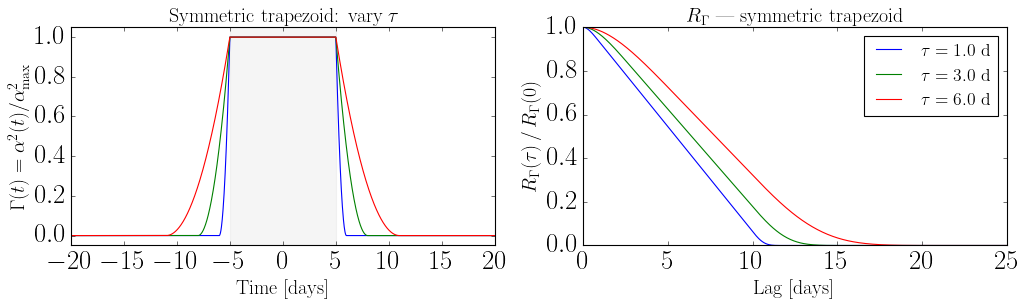

In [15]:
t_env = np.linspace(-25, 25, 2000)

def trapezoid_alpha(t, lspot, tau_em, tau_dec=None):
    """Normalized trapezoidal envelope alpha(t)/alpha_max."""
    if tau_dec is None:
        tau_dec = tau_em
    rise  = (np.maximum(t + lspot/2 + tau_em, 0) - np.maximum(t + lspot/2, 0)) / tau_em
    decay = (np.maximum(t - lspot/2, 0) - np.maximum(t - lspot/2 - tau_dec, 0)) / tau_dec
    return np.clip(rise - decay, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: envelope shape for different tau
ax = axes[0]
lspot = 10.0
for tau in [1.0, 3.0, 6.0]:
    gamma = trapezoid_alpha(t_env, lspot, tau) ** 2
    ax.plot(t_env, gamma, label=f"$\\tau={tau}$ d")
ax.axvspan(-lspot/2, lspot/2, alpha=0.08, color="gray", label=f"plateau ($\\ell={{\\rm spot}}={lspot}$ d)")
ax.set_xlabel("Time [days]", fontsize=18)
ax.set_ylabel(r"$\Gamma(t) = \alpha^2(t)/\alpha_{\rm max}^2$", fontsize=18)
ax.set_title("Symmetric trapezoid: vary $\\tau$", fontsize=18)
ax.set_xlim(-20, 20)
ax.set_ylim(-0.05, 1.05)
# right: R_Gamma
ax = axes[1]
lags = np.linspace(0, 30, 600)
for tau in [1.0, 3.0, 6.0]:
    h = dict(hparam_ref, lspot=lspot, tau=tau)
    k = AnalyticKernel(h)
    R = np.asarray(k.R_Gamma(lags))
    ax.plot(lags, R / R[0], label=f"$\\tau={tau}$ d")
ax.axhline(0, color="gray", lw=0.7)
ax.set_xlabel("Lag [days]", fontsize=18)
ax.set_ylabel(r"$R_\Gamma(\tau)\,/\,R_\Gamma(0)$", fontsize=18)
ax.set_title("$R_\\Gamma$ — symmetric trapezoid", fontsize=18)
ax.legend(fontsize=16)
ax.set_xlim(0, 25)

plt.tight_layout()
plt.show()

---
### 3.2 Asymmetric trapezoid

**Signature keys:** `tau_em`, `tau_dec`

A generalisation of the symmetric case with independent emergence ($\tau_{\rm em}$) and decay ($\tau_{\rm dec}$) timescales.  This lets the spot rise quickly but disappear slowly (or vice versa).

$$\frac{\alpha(t)}{\alpha_{\rm max}} = \begin{cases}
\dfrac{t + \ell/2 + \tau_{\rm em}}{\tau_{\rm em}} & -\ell/2 - \tau_{\rm em} \le t < -\ell/2 \\[6pt]
1 & -\ell/2 \le t \le \ell/2 \\[6pt]
\dfrac{\ell/2 + \tau_{\rm dec} - t}{\tau_{\rm dec}} & \ell/2 < t \le \ell/2 + \tau_{\rm dec} \\[6pt]
0 & \text{otherwise}
\end{cases}$$

`resolve_hparam` injects a scalar `tau = (tau_em + tau_dec) / 2` for modules that need a single timescale.

**Required `hparam` keys:** `peq`, `kappa`, `inc`, `lspot`, `tau_em`, `tau_dec` + one amplitude key.

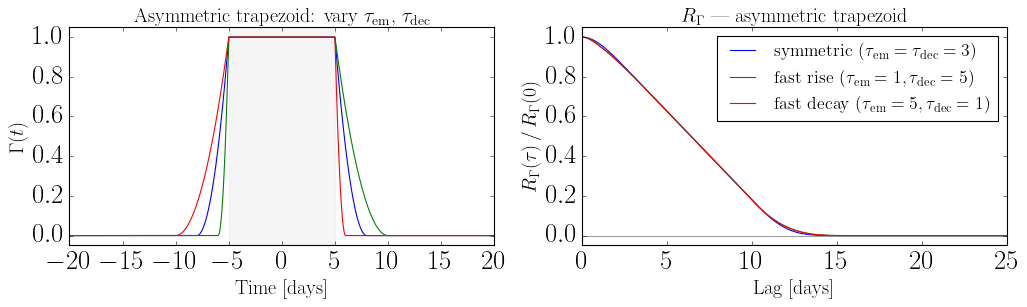

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
lspot = 10.0

# left: envelope shapes
ax = axes[0]
configs = [
    (3.0, 3.0, "symmetric ($\\tau_{\\rm em}=\\tau_{\\rm dec}=3$)"),
    (1.0, 5.0, "fast rise ($\\tau_{\\rm em}=1, \\tau_{\\rm dec}=5$)"),
    (5.0, 1.0, "fast decay ($\\tau_{\\rm em}=5, \\tau_{\\rm dec}=1$)"),
]
for tau_em, tau_dec, label in configs:
    gamma = trapezoid_alpha(t_env, lspot, tau_em, tau_dec) ** 2
    ax.plot(t_env, gamma, label=label)
ax.axvspan(-lspot/2, lspot/2, alpha=0.08, color="gray")
ax.set_xlabel("Time [days]", fontsize=18)
ax.set_ylabel(r"$\Gamma(t)$", fontsize=18)
ax.set_title("Asymmetric trapezoid: vary $\\tau_{\\rm em}$, $\\tau_{\\rm dec}$", fontsize=18)
ax.set_xlim(-20, 20)
ax.set_ylim(-0.05, 1.05)

# right: R_Gamma
ax = axes[1]
lags = np.linspace(0, 30, 600)
for tau_em, tau_dec, label in configs:
    h = dict(hparam_ref, lspot=lspot, tau_em=tau_em, tau_dec=tau_dec)
    del h["tau"]  # tau_em+tau_dec takes priority; remove tau to avoid ambiguity
    k = AnalyticKernel(h)
    R = np.asarray(k.R_Gamma(lags))
    ax.plot(lags, R / R[0], label=label)
ax.axhline(0, color="gray", lw=0.7)
ax.set_xlabel("Lag [days]", fontsize=18)
ax.set_ylabel(r"$R_\Gamma(\tau)\,/\,R_\Gamma(0)$", fontsize=18)
ax.set_title("$R_\\Gamma$ — asymmetric trapezoid", fontsize=18)
ax.legend(fontsize=16)
ax.set_xlim(0, 25)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

---
### 3.3 Skew-normal

**Signature keys:** `sigma_sn`, `n_sn`

The skew-normal envelope is taken from Eq. (1) of [Baranyi et al. (2021) A&A 653, A59](https://www.aanda.org/articles/aa/pdf/2021/09/aa40731-21.pdf), where it was fit to observed sunspot group area curves:

$$\Gamma_{\rm SN}(t) = \frac{1}{\Gamma_{\rm max}}
  \exp\!\left(-\frac{t^2}{2\sigma_{\rm sn}^2}\right)
  \left[1 + {\rm erf}\!\left(\frac{n_{\rm sn}\,t}{\sigma_{\rm sn}\sqrt{2}}\right)\right]$$

normalised so the peak value equals 1.

| Key | Description | Units | Typical range |
|:---|:---|:---|:---|
| `sigma_sn` | Scale parameter — controls the overall width | days | 1–10 |
| `n_sn` | Skewness parameter | dimensionless | −5 to 5 |

The skewness parameter $n_{\rm sn}$ sets the asymmetry:
- $n_{\rm sn} = 0$: symmetric Gaussian envelope
- $n_{\rm sn} < 0$: rapid rise, slow decay (typical sunspot behaviour)
- $n_{\rm sn} > 0$: slow rise, rapid decay

Unlike the trapezoid envelopes, the skew-normal has no plateau, so `lspot` is not meaningful.  Set `lspot=0` when using this envelope (it is stored but not used in $R_\Gamma$).

`resolve_hparam` injects `tau = sigma_sn` as the scalar timescale.

Because $R_\Gamma^{\rm SN}$ has no closed form, `AnalyticKernel` precomputes it numerically at construction time via `compute_R_Gamma_numerical` and stores the result on a fine lag grid for fast interpolation.

**Required `hparam` keys:** `peq`, `kappa`, `inc`, `lspot` (set to `0`), `sigma_sn`, `n_sn` + one amplitude key.

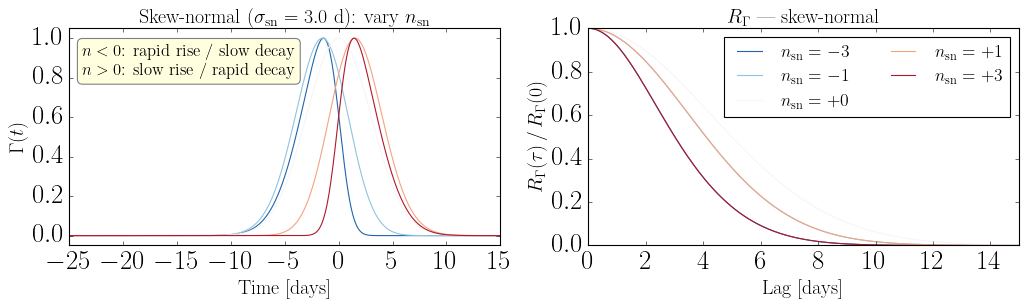

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: envelope shape for different n_sn
ax = axes[0]
sigma_sn = 3.0
n_sn_values = [-3.0, -1.0, 0.0, 1.0, 3.0]
colors = plt.cm.RdBu_r(np.linspace(0.1, 0.9, len(n_sn_values)))

for n_sn, color in zip(n_sn_values, colors):
    env_func = _skew_normal_envelope_func(sigma_sn, n_sn)
    gamma = env_func(t_env)
    ax.plot(t_env, gamma, color=color, label=f"$n_{{\\rm sn}}={n_sn:+.0f}$")

ax.set_xlabel("Time [days]", fontsize=18)
ax.set_ylabel(r"$\Gamma(t)$", fontsize=18)
ax.set_title(f"Skew-normal ($\\sigma_{{\\rm sn}}={sigma_sn}$ d): vary $n_{{\\rm sn}}$", fontsize=18)
ax.set_xlim(-25, 15)
ax.set_ylim(-0.05, 1.05)
ax.text(0.03, 0.93, "$n<0$: rapid rise / slow decay\n$n>0$: slow rise / rapid decay",
        transform=ax.transAxes, fontsize=15, va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))

# right: R_Gamma for different n_sn
ax = axes[1]
lags = np.linspace(0, 25, 500)
for n_sn, color in zip(n_sn_values, colors):
    h = dict(hparam_ref, lspot=0.0, sigma_sn=sigma_sn, n_sn=n_sn)
    del h["tau"]
    k = AnalyticKernel(h)
    R = np.asarray(k.R_Gamma(lags))
    ax.plot(lags, R / R[0], color=color, label=f"$n_{{\\rm sn}}={n_sn:+.0f}$")

ax.axhline(0, color="gray", lw=0.7)
ax.set_xlabel("Lag [days]", fontsize=18)
ax.set_ylabel(r"$R_\Gamma(\tau)\,/\,R_\Gamma(0)$", fontsize=18)
ax.set_title("$R_\\Gamma$ — skew-normal", fontsize=18)
ax.legend(fontsize=16, ncol=2)
ax.set_xlim(0, 15)

plt.tight_layout()
plt.show()

---
## 4 — Comparing all three envelopes

We match the **effective timescale** across models so that $R_\Gamma$ decays over the same lag range:

- symmetric trapezoid: `tau=3`, `lspot=10` → lifetime = $\ell + 2\tau = 16$ d
- asymmetric trapezoid: `tau_em=1.5`, `tau_dec=4.5`, same `lspot=10` → same mean lifetime
- skew-normal: `sigma_sn=3`, `n_sn=-1.5` → effective timescale ≈ $2\sigma_{\rm sn} = 6$ d

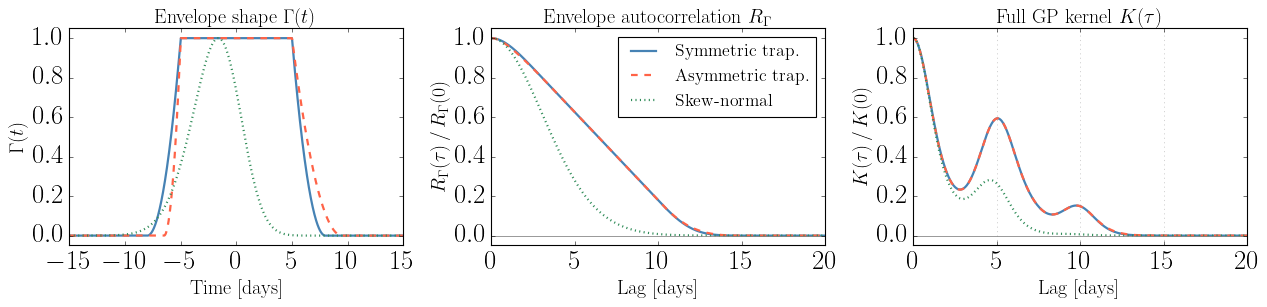

In [29]:
# Build one kernel per envelope
hparam_sym = dict(peq=5.0, kappa=0.2, inc=np.pi/3,
                  lspot=10.0, tau=3.0, sigma_k=0.01)

hparam_asym = dict(peq=5.0, kappa=0.2, inc=np.pi/3,
                   lspot=10.0, tau_em=1.5, tau_dec=4.5, sigma_k=0.01)

hparam_sn = dict(peq=5.0, kappa=0.2, inc=np.pi/3,
                 lspot=0.0, sigma_sn=3.0, n_sn=-1.5, sigma_k=0.01)

k_sym  = AnalyticKernel(hparam_sym,  n_harmonics=3)
k_asym = AnalyticKernel(hparam_asym, n_harmonics=3)
k_sn   = AnalyticKernel(hparam_sn,   n_harmonics=3)

t_env = np.linspace(-25, 25, 2000)
lags  = np.linspace(0, 40, 800)

# Envelope shapes
gamma_sym  = trapezoid_alpha(t_env, 10.0, 3.0) ** 2
gamma_asym = trapezoid_alpha(t_env, 10.0, 1.5, 4.5) ** 2
gamma_sn   = _skew_normal_envelope_func(3.0, -1.5)(t_env)

R_sym  = np.asarray(k_sym.R_Gamma(lags))
R_asym = np.asarray(k_asym.R_Gamma(lags))
R_sn   = np.asarray(k_sn.R_Gamma(lags))

K_sym  = k_sym.kernel(lags)
K_asym = k_asym.kernel(lags)
K_sn   = k_sn.kernel(lags)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

labels = ["Symmetric trap.", "Asymmetric trap.", "Skew-normal"]
colors = ["steelblue", "tomato", "seagreen"]
lss    = ["-", "--", ":"]

# Envelope shapes
ax = axes[0]
for gamma, label, color, ls in zip(
        [gamma_sym, gamma_asym, gamma_sn], labels, colors, lss):
    ax.plot(t_env, gamma, color=color, ls=ls, lw=2, label=label)
ax.set_xlabel("Time [days]", fontsize=18)
ax.set_ylabel(r"$\Gamma(t)$", fontsize=18)
ax.set_title("Envelope shape $\\Gamma(t)$", fontsize=18)
ax.set_xlim(-15, 15)
ax.set_ylim(-0.05, 1.05)
# R_Gamma
ax = axes[1]
for R, label, color, ls in zip(
        [R_sym, R_asym, R_sn], labels, colors, lss):
    ax.plot(lags, R / R[0], color=color, ls=ls, lw=2, label=label)
ax.axhline(0, color="gray", lw=0.7)
ax.set_xlabel("Lag [days]", fontsize=18)
ax.set_ylabel(r"$R_\Gamma(\tau)\,/\,R_\Gamma(0)$", fontsize=18)
ax.set_title("Envelope autocorrelation $R_\\Gamma$", fontsize=18)
ax.set_xlim(0, 20)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=16)

# Full kernel
ax = axes[2]
for K, label, color, ls in zip(
        [K_sym, K_asym, K_sn], labels, colors, lss):
    ax.plot(lags, K / K[0], color=color, ls=ls, lw=2, label=label)
for ii in range(1, 9):
    ax.axvline(ii * hparam_sym["peq"], color="gray", ls=":", alpha=0.4, lw=0.8)
ax.axhline(0, color="gray", lw=0.7)
ax.set_xlabel("Lag [days]", fontsize=18)
ax.set_ylabel(r"$K(\tau)\,/\,K(0)$", fontsize=18)
ax.set_title("Full GP kernel $K(\\tau)$", fontsize=18)
ax.set_xlim(0, 20)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

### Power spectral density

The PSD is the Fourier transform of $K(\tau)$.  Peaks appear at the rotation frequency $f = 1/P_{\rm eq}$ and its harmonics.  The envelope shape controls the height and width of these peaks.

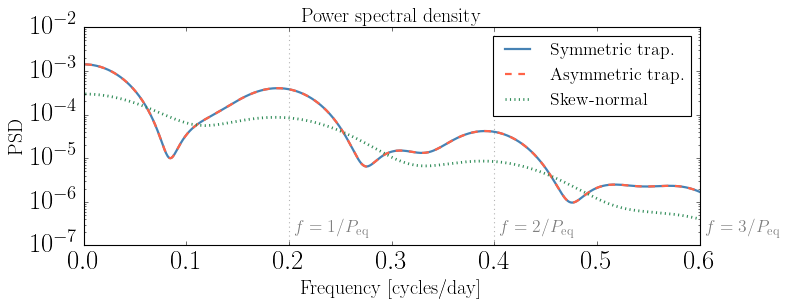

In [31]:
omega = np.linspace(0.01, 6 * np.pi / hparam_sym["peq"], 800)

freq_sym,  psd_sym  = k_sym.compute_psd(omega)
freq_asym, psd_asym = k_asym.compute_psd(omega)
freq_sn,   psd_sn   = k_sn.compute_psd(omega)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(freq_sym,  psd_sym,  color="steelblue", ls="-",  lw=2, label="Symmetric trap.")
ax.semilogy(freq_asym, psd_asym, color="tomato",    ls="--", lw=2, label="Asymmetric trap.")
ax.semilogy(freq_sn,   psd_sn,   color="seagreen",  ls=":",  lw=2.5, label="Skew-normal")
for ii in range(1, 4):
    ax.axvline(ii / hparam_sym["peq"], color="gray", ls=":", alpha=0.6, lw=1)
    ax.text(ii / hparam_sym["peq"] + 0.005, ax.get_ylim()[0] * 2,
            f"$f={ii}/P_{{\\rm eq}}$", fontsize=16, color="gray")
ax.set_xlabel("Frequency [cycles/day]", fontsize=18)
ax.set_ylabel("PSD", fontsize=18)
ax.set_title("Power spectral density", fontsize=18)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()

---
## 5 — Computing $R_\Gamma$ for a custom envelope

If you add your own envelope (see *Custom Envelope Functions* tutorial), you can use `compute_R_Gamma_numerical` to precompute $R_\Gamma$ for any callable $\Gamma(t)$ without deriving the autocorrelation analytically.

```python
lag_grid, R_vals = compute_R_Gamma_numerical(
    envelope_func,   # f(t: np.ndarray) -> np.ndarray
    tau_ref,         # reference timescale [days] — sets grid extent
    n_grid=4096,     # number of time-grid points
    extent=12.0,     # grid half-width in units of tau_ref
)
# Evaluate at any lag:
R_at_lag = jnp.interp(jnp.abs(lag), lag_grid, R_vals)
```

The function uses FFT-based autocorrelation.  A grid width of `extent * tau_ref` on each side of zero is sufficient when the envelope is negligible beyond that range.  For heavy-tailed envelopes, increase `extent`.

Below we verify that the numerical result matches the analytic formula for a Gaussian envelope $\Gamma(t) = \exp(-t^2/2\sigma^2)$, for which $R_\Gamma(\tau) = \sigma\sqrt{\pi}\exp(-\tau^2/4\sigma^2)$.

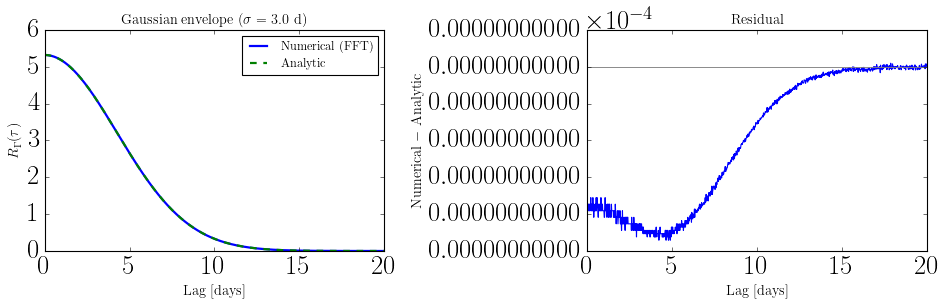

Max absolute residual: 2.35e-14


In [32]:
sigma_gauss = 3.0

# Numerical
def gaussian_envelope(t):
    return np.exp(-t**2 / (2 * sigma_gauss**2))

lag_grid, R_num = compute_R_Gamma_numerical(gaussian_envelope, tau_ref=sigma_gauss)
lag_grid = np.asarray(lag_grid)
R_num    = np.asarray(R_num)

# Analytic: R_Gamma(tau) = sigma * sqrt(pi) * exp(-tau^2 / (4*sigma^2))
R_analytic = sigma_gauss * np.sqrt(np.pi) * np.exp(-lag_grid**2 / (4 * sigma_gauss**2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(lag_grid, R_num,      label="Numerical (FFT)", lw=2)
ax.plot(lag_grid, R_analytic, label="Analytic", ls="--", lw=2)
ax.set_xlim(0, 20)
ax.set_xlabel("Lag [days]", fontsize=13)
ax.set_ylabel(r"$R_\Gamma(\tau)$", fontsize=13)
ax.set_title(f"Gaussian envelope ($\\sigma={sigma_gauss}$ d)", fontsize=13)
ax.legend(fontsize=11)

ax = axes[1]
residual = R_num - R_analytic
ax.plot(lag_grid, residual)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlim(0, 20)
ax.set_xlabel("Lag [days]", fontsize=13)
ax.set_ylabel("Numerical − Analytic", fontsize=13)
ax.set_title("Residual", fontsize=13)
ax.ticklabel_format(axis="y", style="sci", scilimits=(-4, -4))

plt.tight_layout()
plt.show()

print(f"Max absolute residual: {np.max(np.abs(residual)):.2e}")

---
## Quick reference

### All `hparam` keys

| Key | Description | Units | Required by |
|:---|:---|:---|:---|
| `peq` | Equatorial rotation period | days | **all envelopes** |
| `kappa` | Differential rotation shear | dimensionless | **all envelopes** |
| `inc` | Stellar inclination | radians | **all envelopes** |
| `lspot` | Spot plateau duration | days | symmetric trap., asymmetric trap. |
| `tau` | Symmetric rise/decay timescale | days | symmetric trapezoid |
| `tau_em` | Emergence timescale | days | asymmetric trapezoid |
| `tau_dec` | Decay timescale | days | asymmetric trapezoid |
| `sigma_sn` | Skew-normal scale (width) | days | skew-normal |
| `n_sn` | Skew-normal skewness ($n<0$: fast rise) | dimensionless | skew-normal |
| `sigma_k` | Kernel amplitude (direct) | — | amplitude mode 1 |
| `nspot_rate` | Spot emergence rate | spots/day | amplitude mode 2 (preferred) |
| `fspot` | Spot contrast fraction $\in[0,1]$ | — | amplitude modes 2, 3 |
| `alpha_max` | Peak spot angular radius | radians | amplitude modes 2, 3 |
| `nspot` | Total spot count (legacy) | count | amplitude mode 3 (legacy) |
| `sigma_n` | White-noise amplitude (optional) | — | `GPSolver` only |

### Minimum hparam by envelope

```python
# Symmetric trapezoid
hparam = dict(peq=..., kappa=..., inc=..., lspot=..., tau=..., sigma_k=...)

# Asymmetric trapezoid (tau_em + tau_dec overrides tau)
hparam = dict(peq=..., kappa=..., inc=..., lspot=..., tau_em=..., tau_dec=..., sigma_k=...)

# Skew-normal  (lspot required by schema; set to 0 — it is not used)
hparam = dict(peq=..., kappa=..., inc=..., lspot=0, sigma_sn=..., n_sn=..., sigma_k=...)

# Physical amplitude (works with any envelope)
hparam = dict(peq=..., kappa=..., inc=..., lspot=..., tau=...,
              nspot_rate=..., fspot=..., alpha_max=...)
```

### Envelope detection rule

The envelope is auto-detected by `resolve_hparam` from the keys present in the dict.  The **most specific match** (largest set of matching signature keys) wins.  Within the same specificity tier, **registration order** is used as a tiebreaker.

| If `hparam` contains… | Detected envelope |
|:---|:---|
| `sigma_sn` and `n_sn` | skew-normal |
| `tau_em` and `tau_dec` | asymmetric trapezoid |
| `tau` | symmetric trapezoid |
| none of the above | `ValueError` |